# Exploratory Analysis: Interest Group Prominence

Dataset: 53,892 mentions across 2,260 organizations from the 114th and 115th U.S. Congress (2015-2019).

This notebook explores the distribution of mentions and prominence across organizations, lobbying expenditure, policy areas, and politician characteristics.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style for all plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Project paths (relative to notebooks/ directory)
PROJECT_ROOT = Path('..').resolve()
DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("✓ Libraries loaded")
print(f"✓ Output directory: {OUTPUT_DIR}")

✓ Libraries loaded
✓ Output directory: C:\Users\kaleb\OneDrive\Desktop\ThesisPipelineRework\outputs\figures


## 1. Data Overview

The dataset has three levels:

- Level 1 (Mentions): Individual interest group mentions in Congressional Record paragraphs
- Level 2 (Organizations): Interest group characteristics (lobbying, age, category, location)
- Level 3 (Politicians): Member characteristics (ideology, committees, voting patterns)

Key Variables:
- `prominence`: Binary indicator (1 = prominent mention, 0 = casual name-drop)
- `LOBBYING11_log`: Log-transformed lobbying expenditure
- `YEARS_EXISTED`: Organization age
- `issue_area`: Policy domain of the speech
- `issue_area_salience_recoded`: Weekly salience for that policy domain
- `dw_nominate`: Member ideology (-1 = liberal, +1 = conservative)
- `issue_maximal_overlap`: Speech in member's core policy area (1 = yes)

In [2]:
# Load the multi-level data
print("Loading multi-level data...")
level1_path = DATA_DIR / "output" / "level1.csv"

df = pd.read_csv(level1_path, low_memory=False)

# Add level1_ prefix to match column references used throughout this notebook
col_map = {
    'org_id': 'level1_org_id',
    'org_name': 'level1_org_name',
    'prominence_prediction': 'level1_prominence',
    'chamber': 'level1_chamber_x',
    'party': 'level1_party',
    'ABBREVCAT': 'level1_ABBREVCAT',
    'CATEGORY': 'level1_CATEGORY',
    'MSHIP_STATUS11': 'level1_MSHIP_STATUS11',
    'OUTSIDE11': 'level1_OUTSIDE11',
    'LOBBYING11': 'level1_LOBBYING11',
    'FOUNDED': 'level1_FOUNDED',
    'LOCATION': 'level1_LOCATION',
    'issue_area': 'level1_issue_area',
    'year_week': 'level1_year_week',
    'memberName': 'level1_memberName',
    'bioGuideId': 'level1_s.bioGuideId',
    'salience': 'level1_salience',
    'interest_group': 'level1_interest_group',
}
df = df.rename(columns={k: v for k, v in col_map.items() if k in df.columns})

# Derive YEARS_EXISTED from founding year
if 'level1_FOUNDED' in df.columns:
    df['level1_FOUNDED'] = pd.to_numeric(df['level1_FOUNDED'], errors='coerce')
    df['level1_YEARS_EXISTED'] = 2018 - df['level1_FOUNDED']

# Ensure LOBBYING11 is numeric
if 'level1_LOBBYING11' in df.columns:
    df['level1_LOBBYING11'] = pd.to_numeric(df['level1_LOBBYING11'], errors='coerce')

print(f"✓ Loaded {len(df):,} rows from {level1_path.name}")
print(f"✓ Columns: {len(df.columns)}")
print(f"\nData shape: {df.shape}")

# Check for key columns
org_cols = [col for col in df.columns if 'org' in col.lower()]
prom_cols = [col for col in df.columns if 'promin' in col.lower()]
speaker_cols = [col for col in df.columns if 'bio' in col.lower() or 'speaker' in col.lower()]

print(f"\nColumns containing 'org': {org_cols}")
print(f"Columns containing 'promin': {prom_cols}")
print(f"Columns containing 'bio' or 'speaker': {speaker_cols}")

print(f"\n{'='*60}")
print("DATASET SUMMARY")
print(f"{'='*60}")
print(f"Total rows: {len(df):,}")
print(f"\nFirst 5 rows:")
print(df.head())

Loading multi-level data...
✓ Loaded 53,892 rows from level1.csv
✓ Columns: 64

Data shape: (53892, 64)

Columns containing 'org': ['level1_org_id', 'level1_org_name']
Columns containing 'promin': ['prominence_score', 'level1_prominence']
Columns containing 'bio' or 'speaker': ['level1_s.bioGuideId', 'state_bio']

DATASET SUMMARY
Total rows: 53,892

First 5 rows:
   level1_org_id                        level1_interest_group  \
0          52997          National Small Business Association   
1           2464  National Federation of Independent Business   
2           3171                                      The Arc   
3           1623                           Human Rights Watch   
4           1623                           Human Rights Watch   

                                     variation  is_acronym  \
0          National Small Business Association       False   
1  National Federation of Independent Business       False   
2                                      The Arc       Fals

## 2. Mention Distribution by Organization

Which organizations appear most frequently and which have the highest share of prominent mentions?

In [3]:
# Create log of lobbying spend first
df['level1_LOBBYING11_log'] = np.log1p(df['level1_LOBBYING11'])

# Aggregate at organization level
org_level = df.groupby('level1_org_id').agg({
    'level1_org_name': 'first',
    'level1_ABBREVCAT': 'first',
    'level1_CATEGORY': 'first',
    'level1_prominence': ['sum', 'count', 'mean'],
    'level1_LOBBYING11_log': 'first',
    'level1_YEARS_EXISTED': 'first',
    'level1_LOCATION': 'first'
}).reset_index()

# Flatten column names
org_level.columns = ['org_id', 'org_name', 'org_category_abbrev', 'org_category_full', 
                     'prominent_mentions', 'total_mentions', 'pct_prominent',
                     'lobbying_log', 'years_existed', 'location']

# Filter to orgs with at least 3 mentions
org_level = org_level[org_level['total_mentions'] >= 3].copy()

print(f"Organizations with 3+ mentions: {len(org_level):,}")
print(f"\nTop 10 by prominent mentions:")
print(org_level.nlargest(10, 'prominent_mentions')[['org_name', 'prominent_mentions', 'total_mentions', 'pct_prominent']])

Organizations with 3+ mentions: 1,560

Top 10 by prominent mentions:
                                               org_name  prominent_mentions  \
933   Planned Parenthood Federation of America      ...                2104   
2160  Planned Parenthood Affiliates of California   ...                2102   
630   National Association for the Advancement of Co...                 442   
2     AARP (American Association of Retired Persons)...                 319   
90    American Civil Liberties Union                ...                 236   
491   Fraternal Order of Police                     ...                 227   
672   National Association of Manufacturers         ...                 224   
14    AFL-CIO (American Federation of Labor and Cong...                 208   
78    American Bar Association                      ...                 202   
1387  Transport Workers Union of America, AFL-CIO   ...                 199   

      total_mentions  pct_prominent  
933             4338   

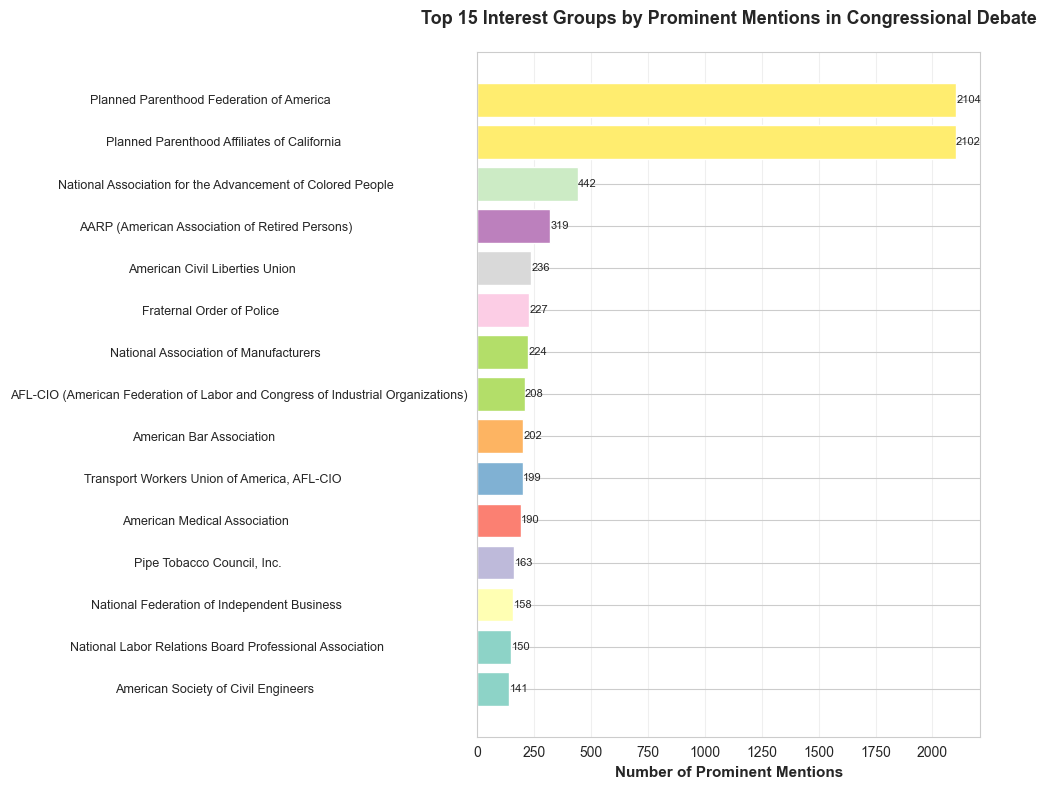

✓ Figure 1 saved


In [4]:
# VISUALIZATION 1: Top 15 organizations by prominent mentions
fig, ax = plt.subplots(figsize=(10, 8))

top_orgs = org_level.nlargest(15, 'prominent_mentions').sort_values('prominent_mentions')

colors = plt.cm.Set3(np.linspace(0, 1, len(top_orgs)))
bars = ax.barh(range(len(top_orgs)), top_orgs['prominent_mentions'], color=colors)

ax.set_yticks(range(len(top_orgs)))
ax.set_yticklabels(top_orgs['org_name'], fontsize=9)
ax.set_xlabel('Number of Prominent Mentions', fontsize=11, fontweight='bold')
ax.set_title('Top 15 Interest Groups by Prominent Mentions in Congressional Debate', 
             fontsize=13, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(top_orgs.iterrows()):
    ax.text(row['prominent_mentions'] + 1, i, f"{int(row['prominent_mentions'])}", 
            va='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig1_top_orgs_by_prominence.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 1 saved")

## 3. Lobbying and Prominence

Relationship between lobbying expenditure and share of prominent mentions.

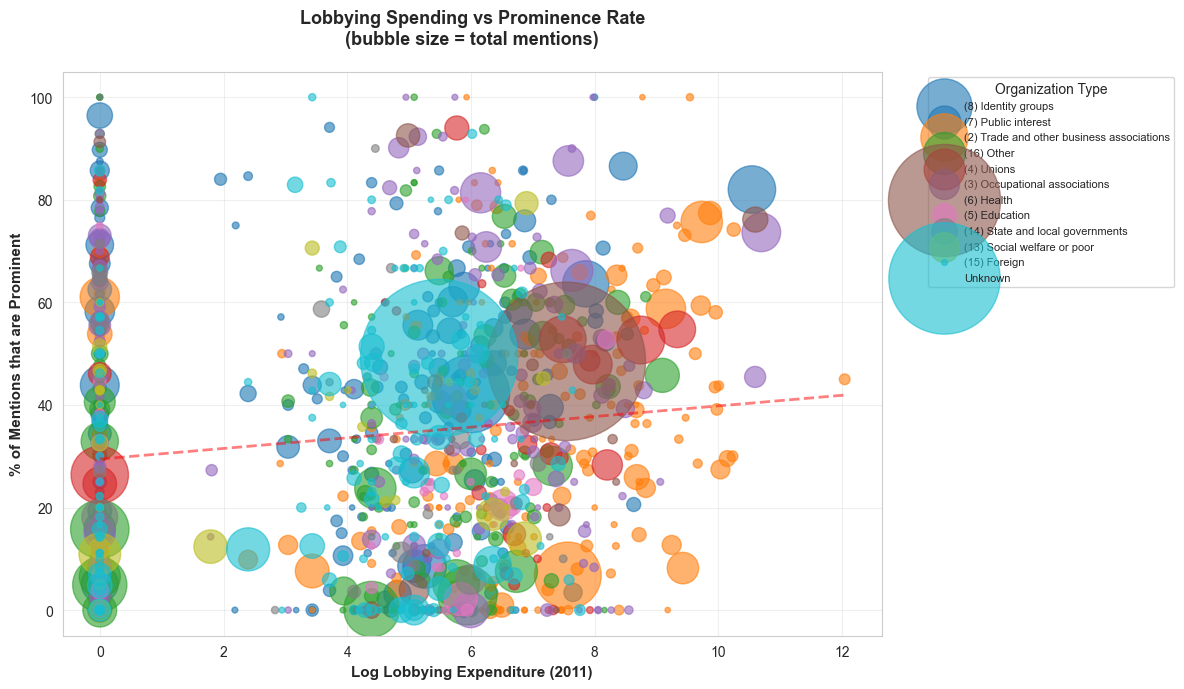

✓ Figure 2 saved

Correlation between lobbying and prominence rate: 0.124


In [5]:
# VISUALIZATION 2: Lobbying vs Prominence Rate
fig, ax = plt.subplots(figsize=(12, 7))

# Filter for orgs with valid lobbying data and sufficient mentions
plot_data = org_level[(org_level['lobbying_log'].notna()) & 
                      (org_level['total_mentions'] >= 5)].copy()

# Create scatter plot with category colors
categories = plot_data['org_category_abbrev'].fillna('Unknown').unique()
colors_map = dict(zip(categories, plt.cm.tab10(np.linspace(0, 1, len(categories)))))

for cat in categories:
    cat_data = plot_data[plot_data['org_category_abbrev'].fillna('Unknown') == cat]
    ax.scatter(cat_data['lobbying_log'], cat_data['pct_prominent'] * 100,
               label=cat, alpha=0.6, s=cat_data['total_mentions']*3,
               color=colors_map[cat])

ax.set_xlabel('Log Lobbying Expenditure (2011)', fontsize=11, fontweight='bold')
ax.set_ylabel('% of Mentions that are Prominent', fontsize=11, fontweight='bold')
ax.set_title('Lobbying Spending vs Prominence Rate\n(bubble size = total mentions)', 
             fontsize=13, fontweight='bold', pad=20)
ax.legend(title='Organization Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

# Add regression line
from scipy.stats import linregress
valid_data = plot_data[['lobbying_log', 'pct_prominent']].dropna()
if len(valid_data) > 0:
    slope, intercept, r_value, p_value, std_err = linregress(
        valid_data['lobbying_log'], valid_data['pct_prominent'])
    x_line = np.array([valid_data['lobbying_log'].min(), valid_data['lobbying_log'].max()])
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line * 100, 'r--', alpha=0.5, linewidth=2,
            label=f'Trend (R²={r_value**2:.3f})')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig2_lobbying_vs_prominence.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 2 saved")
print(f"\nCorrelation between lobbying and prominence rate: {valid_data.corr().iloc[0,1]:.3f}")

## 4. Issue Salience and Policy Overlap

Prominence rates by policy area, issue salience, and whether the speaker sits on a relevant committee.

In [6]:
# VISUALIZATION 3: Overlap vs Non-overlap comparison
if 'level1_issue_maximal_overlap' in df.columns:
    overlap_data = df.groupby('level1_issue_maximal_overlap')['level1_prominence'].agg(['mean', 'count', 'sum'])
    overlap_data['pct_prominent'] = overlap_data['mean'] * 100
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    labels = ['No Overlap\n(Outside core area)', 'Overlap\n(In core policy area)']
    x_pos = np.arange(len(labels))
    
    bars = ax.bar(x_pos, overlap_data['pct_prominent'], 
                   color=['#e74c3c', '#27ae60'], alpha=0.7, edgecolor='black')
    
    ax.set_ylabel('% Prominent Mentions', fontsize=11, fontweight='bold')
    ax.set_xlabel('Member Speaking in Their Core Policy Area?', fontsize=11, fontweight='bold')
    ax.set_title('Prominence Rate: Core Policy Area vs Other Issues\n(Higher when members speak "in their lane")', 
                 fontsize=13, fontweight='bold', pad=20)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels and counts
    for i, (idx, row) in enumerate(overlap_data.iterrows()):
        ax.text(i, row['pct_prominent'] + 1, f"{row['pct_prominent']:.1f}%", 
                ha='center', va='bottom', fontsize=11, fontweight='bold')
        ax.text(i, -2, f"n={int(row['count']):,}", 
                ha='center', va='top', fontsize=8, style='italic')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig3_overlap_vs_prominence.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Figure 3 saved")
    print(f"\nProminence rate in core area: {overlap_data.loc[1, 'pct_prominent']:.1f}%")
    print(f"Prominence rate outside core: {overlap_data.loc[0, 'pct_prominent']:.1f}%")
    print(f"Difference: {overlap_data.loc[1, 'pct_prominent'] - overlap_data.loc[0, 'pct_prominent']:.1f} percentage points")
else:
    print("⚠ 'level1_issue_maximal_overlap' column not found")

⚠ 'level1_issue_maximal_overlap' column not found


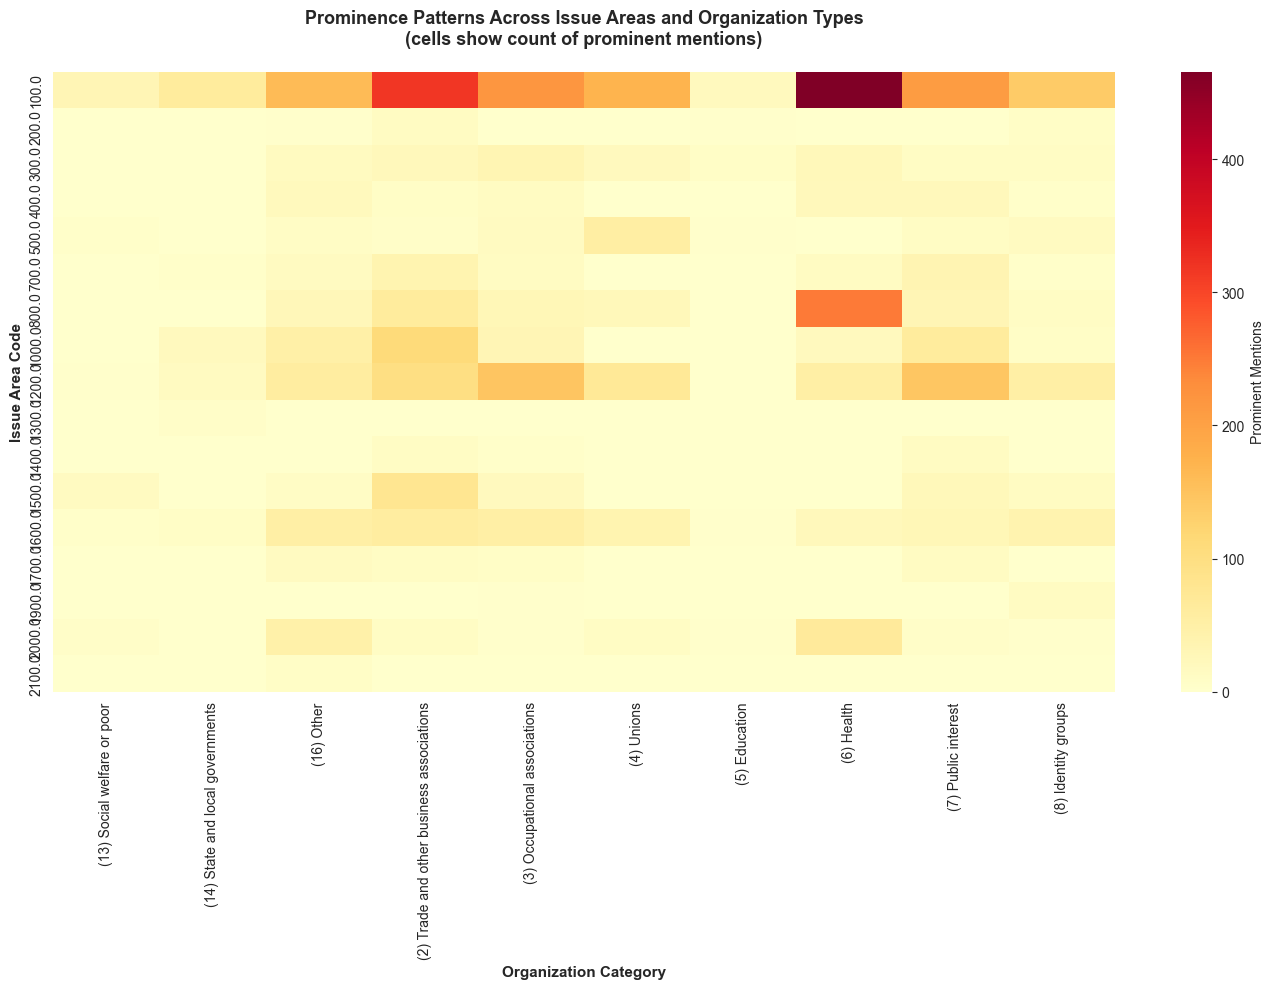

✓ Figure 4 saved


In [7]:
# VISUALIZATION 4: Heatmap - Prominence by Issue Area and Org Category
if 'level1_issue_area' in df.columns and 'level1_ABBREVCAT' in df.columns:
    # Create pivot table
    heatmap_data = df.groupby(['level1_issue_area', 'level1_ABBREVCAT'])['level1_prominence'].agg(['sum', 'count'])
    heatmap_data = heatmap_data[heatmap_data['count'] >= 10]  # Filter for reliability
    heatmap_pivot = heatmap_data['sum'].unstack(fill_value=0)
    
    if not heatmap_pivot.empty:
        fig, ax = plt.subplots(figsize=(14, 10))
        
        sns.heatmap(heatmap_pivot, cmap='YlOrRd', annot=False, fmt='d', 
                    cbar_kws={'label': 'Prominent Mentions'}, ax=ax)
        
        ax.set_xlabel('Organization Category', fontsize=11, fontweight='bold')
        ax.set_ylabel('Issue Area Code', fontsize=11, fontweight='bold')
        ax.set_title('Prominence Patterns Across Issue Areas and Organization Types\n(cells show count of prominent mentions)', 
                     fontsize=13, fontweight='bold', pad=20)
        
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'fig4_heatmap_issue_org.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("✓ Figure 4 saved")
    else:
        print("⚠ Not enough data for heatmap")
else:
    print("⚠ Required columns not found for heatmap")

## 5. Member-Level Patterns

Prominence patterns by party, chamber, ideology, and committee assignment.

In [8]:
# Aggregate at member level
if 'level1_s.bioGuideId' in df.columns:
    agg_dict = {
        'level1_memberName': 'first',
        'level1_party': 'first',
        'level1_prominence': ['sum', 'count', 'mean'],
        'level1_org_id': 'nunique'
    }
    # Only include ideology if available
    if 'level1_dw_nominate' in df.columns:
        agg_dict['level1_dw_nominate'] = 'first'

    member_level = df.groupby('level1_s.bioGuideId').agg(agg_dict).reset_index()

    if 'level1_dw_nominate' in df.columns:
        member_level.columns = ['bioGuideId', 'name', 'party', 'ideology',
                                'prominent_mentions', 'total_mentions', 'pct_prominent', 'unique_orgs']
    else:
        member_level.columns = ['bioGuideId', 'name', 'party',
                                'prominent_mentions', 'total_mentions', 'pct_prominent', 'unique_orgs']
        member_level['ideology'] = np.nan

    # Filter for members with sufficient mentions
    member_level = member_level[member_level['total_mentions'] >= 10].copy()

    print(f"Members with 10+ interest group mentions: {len(member_level):,}")
    print(f"\nTop 10 members by prominence rate:")
    print(member_level.nlargest(10, 'pct_prominent')[['name', 'party', 'pct_prominent', 'total_mentions']])
else:
    print("Member-level analysis requires 'level1_s.bioGuideId' column")

Members with 10+ interest group mentions: 310

Top 10 members by prominence rate:
                      name party  pct_prominent  total_mentions
141          Franks, Trent     R       0.953488              43
423        Sinema, Kyrsten     D       0.916667              24
97           Cramer, Kevin     R       0.900000              10
200           Hahn, Janice     D       0.900000              10
459          Whitfield, Ed     R       0.888889              27
241        Kelly, Robin L.     D       0.880000              25
6       Abraham, Ralph Lee     R       0.857143              14
68   Culberson, John Abney     R       0.857143              14
195         Huelskamp, Tim     R       0.846154              13
67   Capito, Shelley Moore     R       0.842105              19


In [9]:
# VISUALIZATION 5: Member Ideology vs Prominence Behavior
if 'level1_s.bioGuideId' in df.columns and 'level1_dw_nominate' in df.columns:
    plot_member = member_level[member_level['ideology'].notna()].copy()
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Color by party
    party_colors = {'R': '#e74c3c', 'D': '#3498db', 'I': '#95a5a6'}
    
    for party in plot_member['party'].unique():
        if pd.isna(party):
            continue
        party_data = plot_member[plot_member['party'] == party]
        ax.scatter(party_data['ideology'], party_data['pct_prominent'] * 100,
                   label=party, alpha=0.6, s=party_data['total_mentions']*2,
                   color=party_colors.get(party, '#95a5a6'))
    
    ax.set_xlabel('DW-NOMINATE Score\n(Liberal ← → Conservative)', fontsize=11, fontweight='bold')
    ax.set_ylabel('% of Interest Group Mentions that are Prominent', fontsize=11, fontweight='bold')
    ax.set_title('Member Ideology vs Prominence Behavior\n(bubble size = total mentions)', 
                 fontsize=13, fontweight='bold', pad=20)
    ax.legend(title='Party', fontsize=10)
    ax.grid(alpha=0.3)
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig5_ideology_vs_prominence.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Figure 5 saved")
    
    # Calculate correlation
    valid = plot_member[['ideology', 'pct_prominent']].dropna()
    if len(valid) > 0:
        corr = valid.corr().iloc[0, 1]
        print(f"\nCorrelation between ideology and prominence rate: {corr:.3f}")
else:
    print("⚠ Cannot create ideology plot - missing required columns")

⚠ Cannot create ideology plot - missing required columns


## 6. Summary Statistics & Key Findings

Let's summarize the key patterns we've discovered:

In [10]:
# Create summary statistics table
print("="*70)
print("KEY FINDINGS SUMMARY")
print("="*70)

print("\n DATASET OVERVIEW")
print(f"  • Total mentions analyzed: {len(df):,}")
print(f"  • Unique organizations: {df['level1_org_id'].nunique():,}")
print(f"  • Unique members of Congress: {df['level1_s.bioGuideId'].nunique():,}")
print(f"  • Overall prominence rate: {df['level1_prominence'].mean()*100:.1f}%")

print("\n ORGANIZATION-LEVEL INSIGHTS")
print(f"  • Organizations with 3+ mentions: {len(org_level):,}")
if 'lobbying_log' in org_level.columns:
    corr_lobbying = org_level[['lobbying_log', 'pct_prominent']].dropna().corr().iloc[0,1]
    print(f"  • Lobbying-prominence correlation: {corr_lobbying:.3f}")
print(f"  • Highest prominence rate: {org_level['pct_prominent'].max()*100:.1f}%")
print(f"  • Median prominence rate: {org_level['pct_prominent'].median()*100:.1f}%")

if 'level1_issue_maximal_overlap' in df.columns:
    overlap_stats = df.groupby('level1_issue_maximal_overlap')['level1_prominence'].mean()
    print("\n SPECIALIZATION EFFECT")
    if 0 in overlap_stats.index and 1 in overlap_stats.index:
        print(f"  • Prominence in core policy area: {overlap_stats[1]*100:.1f}%")
        print(f"  • Prominence outside core area: {overlap_stats[0]*100:.1f}%")
        print(f"  • Specialization bonus: +{(overlap_stats[1]-overlap_stats[0])*100:.1f} percentage points")

if 's.bioGuideId' in df.columns:
    print("\n MEMBER-LEVEL PATTERNS")
    print(f"  • Members with 10+ mentions: {len(member_level):,}")
    print(f"  • Average mentions per member: {member_level['total_mentions'].mean():.1f}")
    print(f"  • Average prominence rate: {member_level['pct_prominent'].mean()*100:.1f}%")
    if 'ideology' in member_level.columns:
        ideology_corr = member_level[['ideology', 'pct_prominent']].dropna().corr().iloc[0,1]
        print(f"  • Ideology-prominence correlation: {ideology_corr:.3f}")

print("\n" + "="*70)

KEY FINDINGS SUMMARY

 DATASET OVERVIEW
  • Total mentions analyzed: 53,892
  • Unique organizations: 2,260
  • Unique members of Congress: 490
  • Overall prominence rate: 35.5%

 ORGANIZATION-LEVEL INSIGHTS
  • Organizations with 3+ mentions: 1,560
  • Lobbying-prominence correlation: 0.117
  • Highest prominence rate: 100.0%
  • Median prominence rate: 31.2%



## Summary

Key descriptive patterns:
- Mention frequency follows a power-law distribution. A small number of organizations account for most mentions.
- Lobbying expenditure correlates with mention frequency but the relationship is not linear.
- Democrats and Republicans mention different organization types at different rates.
- Health and defense policy areas generate the most interest group mentions.

These patterns motivate the regression models in Analysis_Showcase.ipynb.